# Multiscale Gradient Scalograms

Because the entire tengri pipeline is differentiable, we can compute
exact Jacobians $\partial \text{SED}(\lambda) / \partial \theta$ via
autodiff. This reveals which wavelengths carry information about each
physical parameter, and at what spectral resolution that information
lives.

This notebook computes gradient SEDs (saliency maps) and explores
wavelet-like scalograms for multiscale sensitivity analysis.

In [1]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fixed,
    Model,
    ParamSpec,
    Uniform,
    load_ssp_data,
)

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

from _plot_style import COLORS, SPECTRAL_FEATURES, setup_style

setup_style()

FIGDIR = os.path.join(_nb_dir, "..", "figures", "reference")
os.makedirs(FIGDIR, exist_ok=True)

## 1. Setup: Parametric Model for Gradient Computation

We use a parametric tsnorm model so that JAX can differentiate with
respect to each physical parameter.

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

spec = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
)

WAVE_OBS = jnp.linspace(3800.0, 9200.0, 300)
model = Model(spec, ssp_data)
model.precompute_spectroscopy(WAVE_OBS)

# Fiducial parameters
FIDUCIAL = {
    "sfh_tsnorm_log_peak_sfr": 1.0,
    "sfh_tsnorm_peak_lbt_gyr": 4.0,
    "sfh_tsnorm_width_gyr": 2.0,
    "sfh_tsnorm_skew": 0.0,
    "sfh_tsnorm_trunc": 5.0,
    "met_logzsol": -0.3,
    "dust_tau_bc": 0.3,
    "dust_tau_diff": 0.5,
    "dust_slope": -0.7,
    "redshift": 0.1,
}

W0321 16:23:37.341893 14988900 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_29148/368149544.py:18: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model.precompute_spectroscopy(WAVE_OBS)


## 2. Jacobian Computation

The Jacobian $J_{ij} = \partial m_i / \partial \theta_j$ gives the
sensitivity of each wavelength pixel to each parameter. This is
computed exactly via `jax.jacobian`.

In [3]:
# Build a function that maps a parameter array to the spectrum
free_names = spec.free_params
fixed_values = spec.get_fixed_values()


def spectrum_from_array(param_array):
    """Map flat parameter array to model spectrum."""
    params = dict(fixed_values)
    for i, name in enumerate(free_names):
        params[name] = param_array[i]
    return model.predict_spectrum(params)


# Fiducial parameter array
param_array = jnp.array([FIDUCIAL[name] for name in free_names])

# Compute Jacobian
jacobian = jax.jacobian(spectrum_from_array)(param_array)
print(f"Jacobian shape: {jacobian.shape}  (n_wave x n_params)")

Jacobian shape: (300, 8)  (n_wave x n_params)


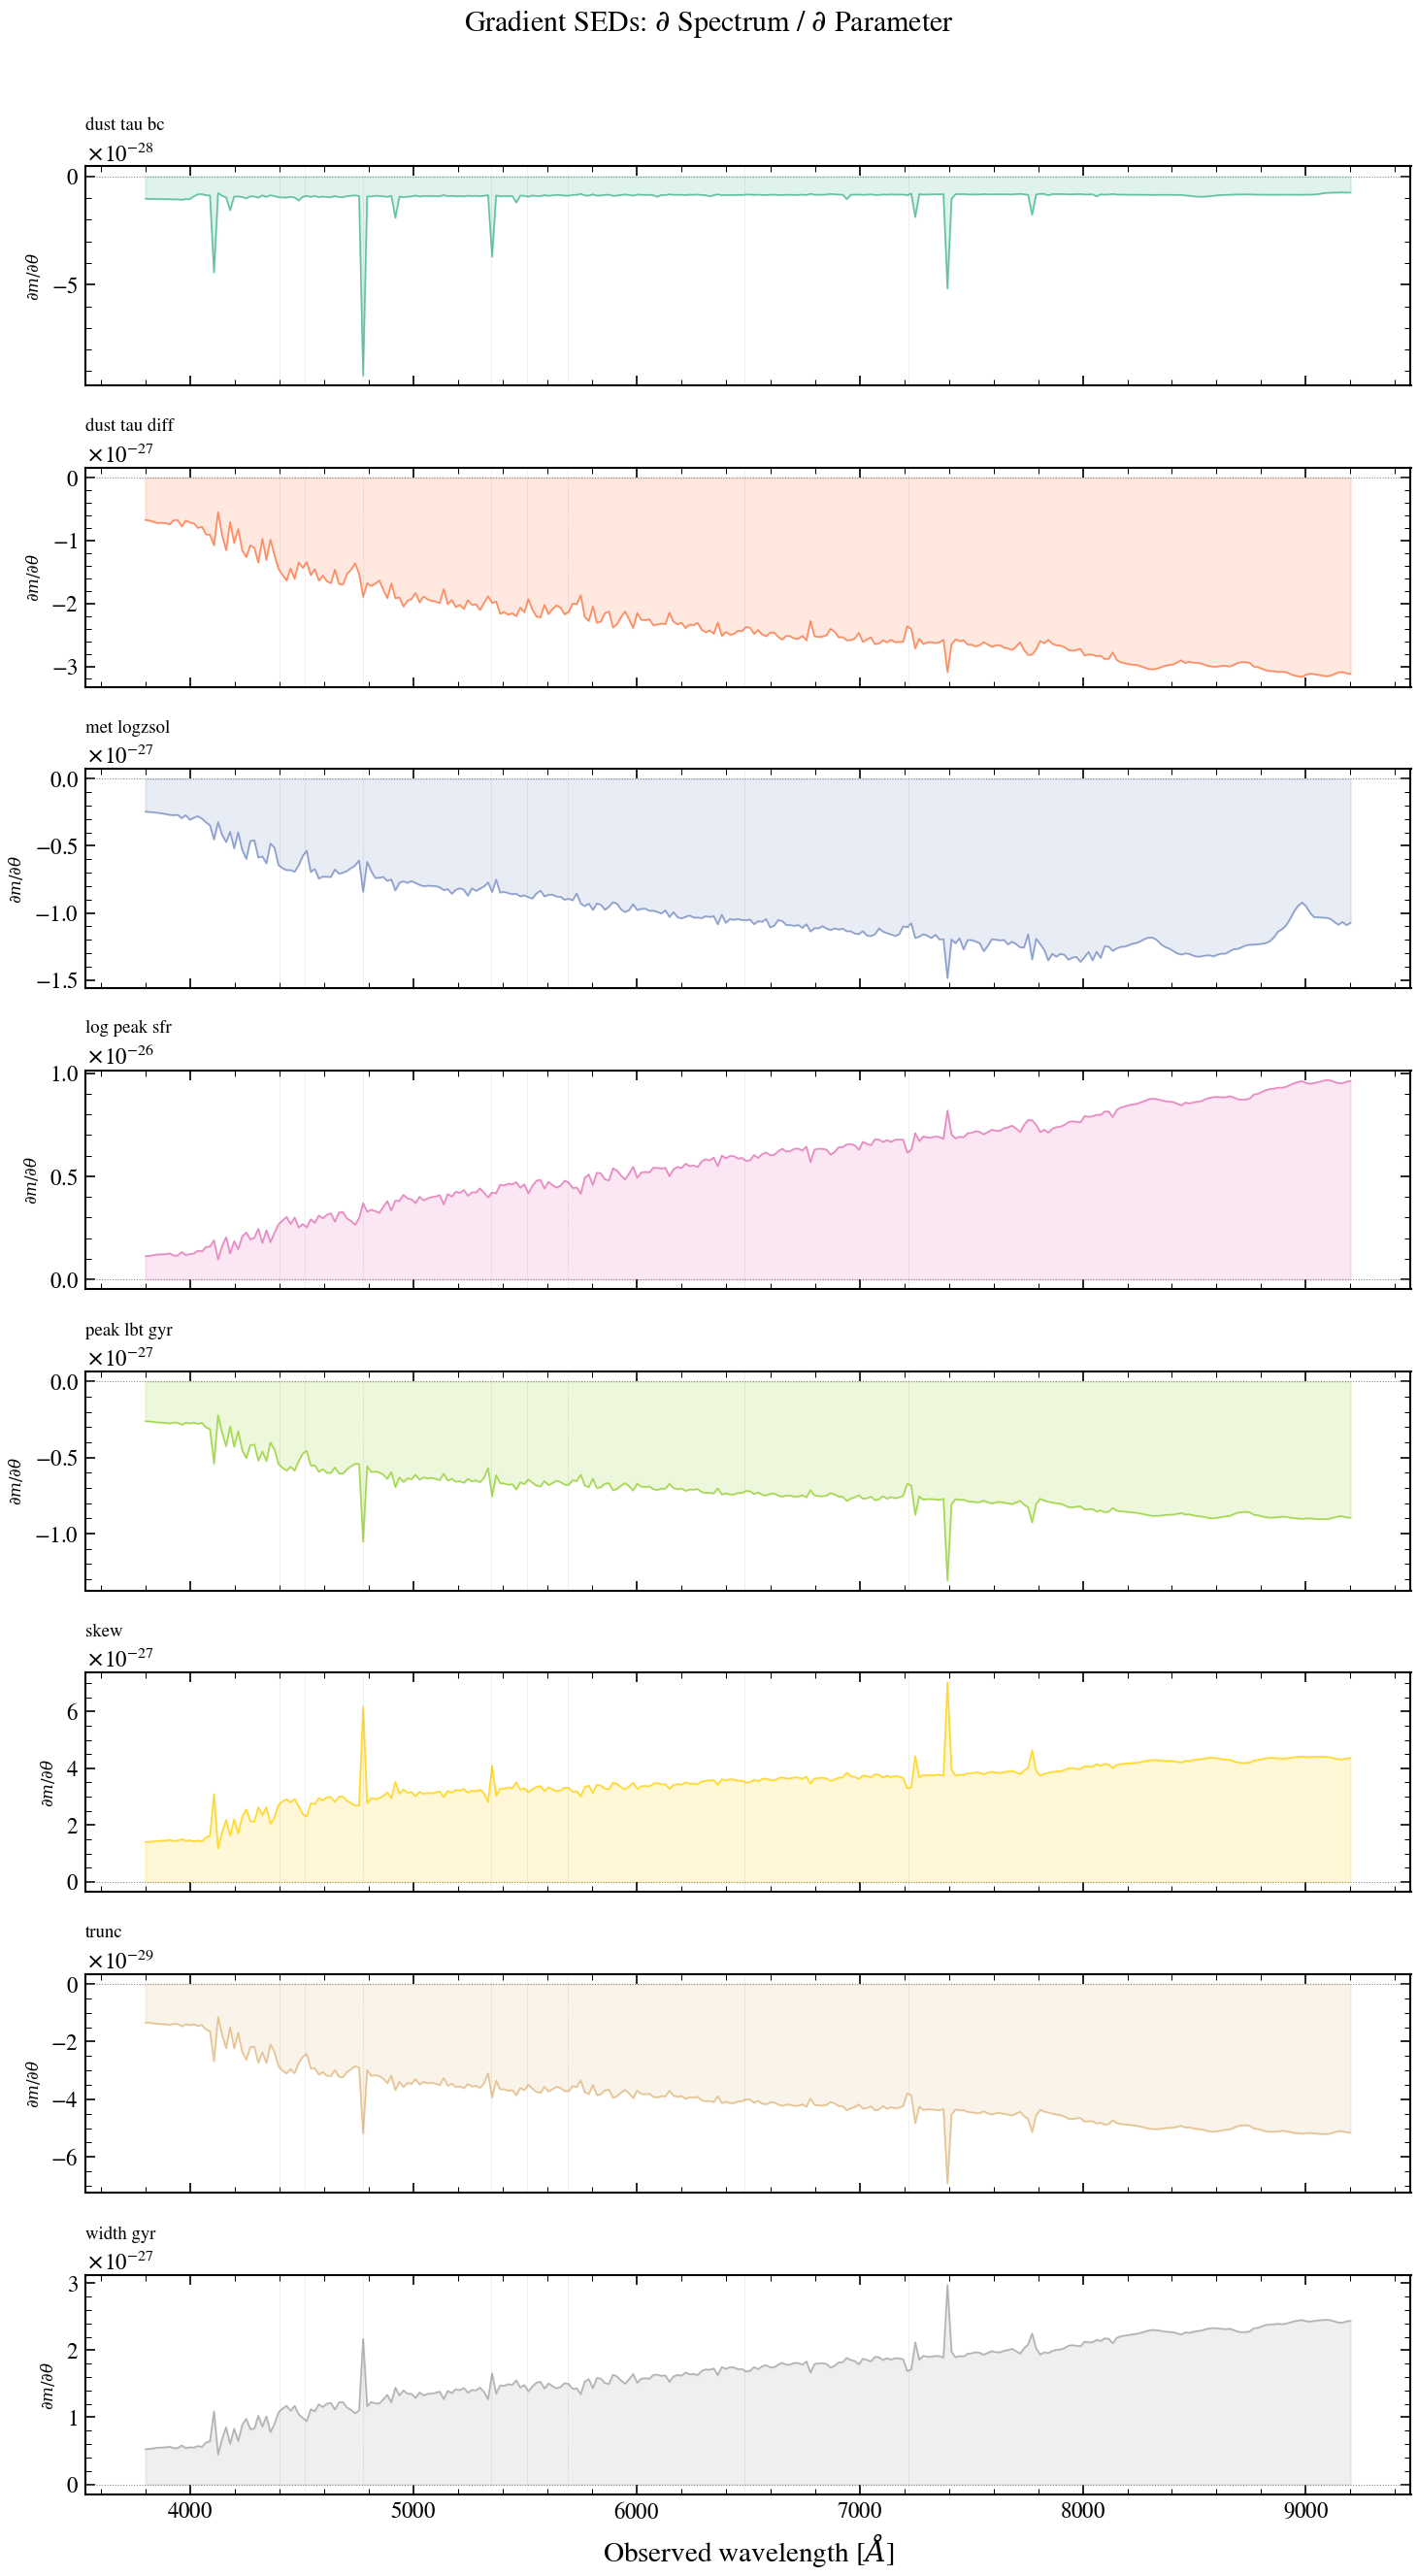

In [4]:
# --- FIGURE 1: Gradient SEDs for all free parameters ---
n_params = len(free_names)
fig, axes = plt.subplots(n_params, 1, figsize=(10, 2.2 * n_params), sharex=True)

param_colors = plt.cm.Set2(np.linspace(0, 1, n_params))

for i, (ax, name) in enumerate(zip(axes, free_names)):
    grad = np.array(jacobian[:, i])
    ax.plot(np.array(WAVE_OBS), grad, color=param_colors[i], lw=0.8)
    ax.fill_between(np.array(WAVE_OBS), 0, grad, alpha=0.2, color=param_colors[i])
    ax.axhline(0, color="grey", ls=":", lw=0.5)
    ax.set_ylabel(r"$\partial m / \partial \theta$", fontsize=8)

    # Clean up parameter name for display
    display_name = name.replace("sfh_tsnorm_", "").replace("_", " ")
    ax.set_title(display_name, fontsize=9, loc="left")

    # Mark spectral features
    for _feat_name, feat_wave in SPECTRAL_FEATURES.items():
        obs_wave = feat_wave * (1 + 0.1)  # redshifted
        if float(WAVE_OBS[0]) < obs_wave < float(WAVE_OBS[-1]):
            ax.axvline(obs_wave, ls=":", color="grey", lw=0.3, alpha=0.5)

axes[-1].set_xlabel(r"Observed wavelength [$\AA$]")
fig.suptitle("Gradient SEDs: $\\partial$ Spectrum / $\\partial$ Parameter", y=1.01)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "07_gradient_seds.png"), bbox_inches="tight")
plt.show()

## 3. Sensitivity Heatmap

A single figure showing the absolute sensitivity $|\partial m / \partial \theta|$
for all parameters simultaneously. This reveals which wavelength ranges are
most informative.

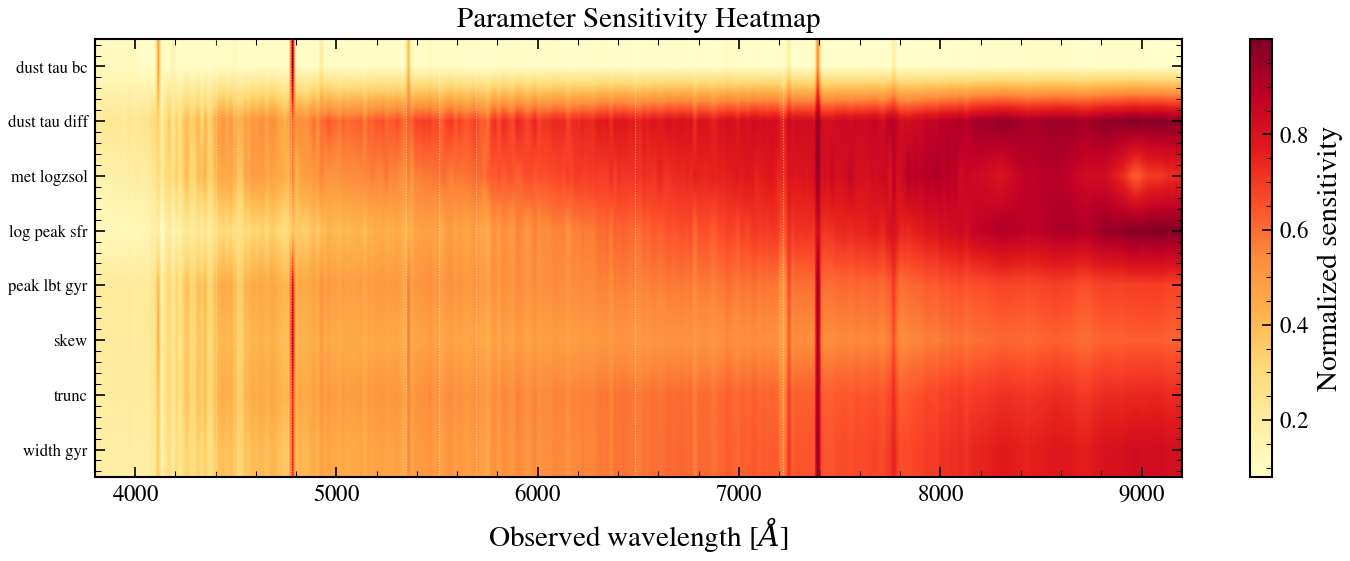

In [5]:
# --- FIGURE 2: Sensitivity heatmap ---
fig, ax = plt.subplots(figsize=(10, 4))

# Normalize each column (parameter) by its max absolute gradient
jac_abs = np.abs(np.array(jacobian))
jac_norm = jac_abs / (jac_abs.max(axis=0, keepdims=True) + 1e-30)

im = ax.imshow(
    jac_norm.T,
    aspect="auto",
    cmap="YlOrRd",
    extent=[float(WAVE_OBS[0]), float(WAVE_OBS[-1]), n_params - 0.5, -0.5],
    interpolation="bilinear",
)
ax.set_yticks(range(n_params))
display_names = [n.replace("sfh_tsnorm_", "").replace("_", " ") for n in free_names]
ax.set_yticklabels(display_names, fontsize=8)
ax.set_xlabel(r"Observed wavelength [$\AA$]")
plt.colorbar(im, ax=ax, label="Normalized sensitivity")
ax.set_title("Parameter Sensitivity Heatmap")

# Mark spectral features
for feat_name, feat_wave in SPECTRAL_FEATURES.items():
    obs_wave = feat_wave * (1 + 0.1)
    if float(WAVE_OBS[0]) < obs_wave < float(WAVE_OBS[-1]):
        ax.axvline(obs_wave, ls=":", color="white", lw=0.5, alpha=0.5)
        ax.annotate(
            feat_name, xy=(obs_wave, -0.7), fontsize=5, color="white", rotation=90, ha="right"
        )

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "07_sensitivity_heatmap.png"), bbox_inches="tight")
plt.show()

## 4. Wavelet-like Scalogram

To understand sensitivity at different spectral scales, we convolve the
gradient SED with Gaussian kernels of varying width and measure the
integrated sensitivity at each scale. This is analogous to a continuous
wavelet transform.

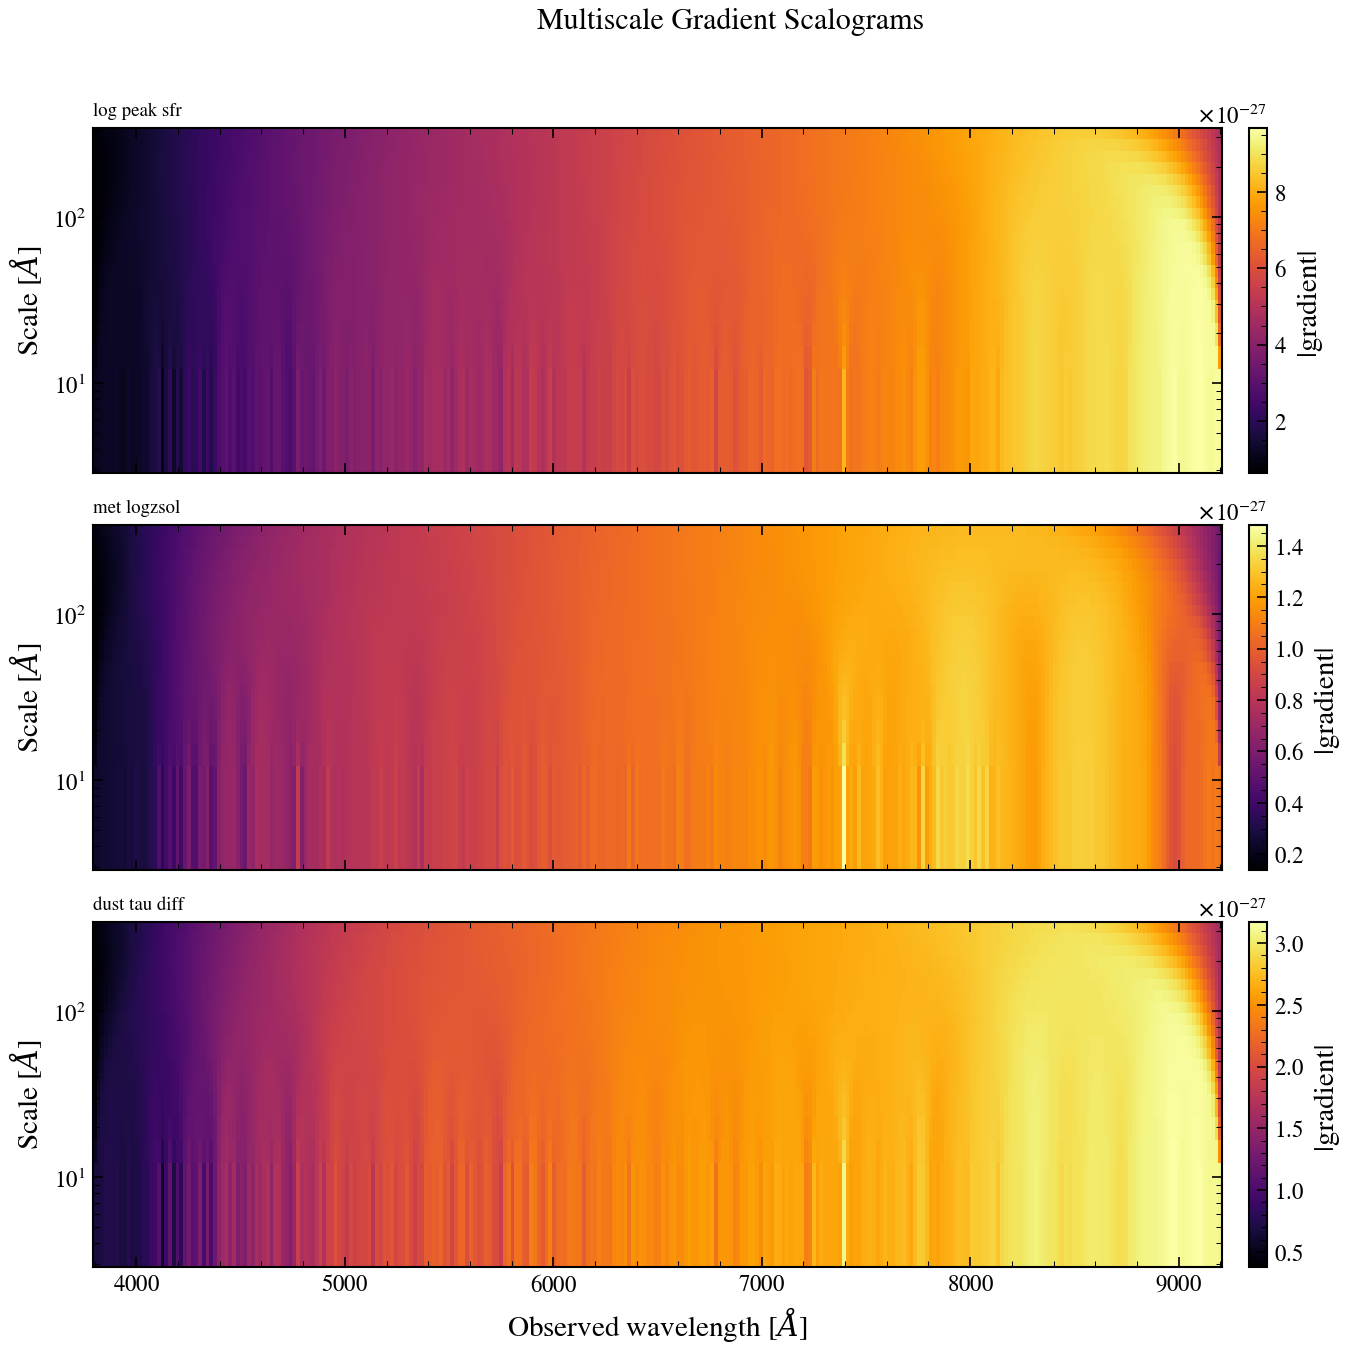

In [6]:
# --- FIGURE 3: Multiscale scalogram for selected parameters ---
params_to_show = ["sfh_tsnorm_log_peak_sfr", "met_logzsol", "dust_tau_diff"]
param_indices = [free_names.index(p) for p in params_to_show]

wave_arr = np.array(WAVE_OBS)
scales = np.logspace(0.5, 2.5, 30)  # Gaussian sigma in Angstrom

fig, axes = plt.subplots(
    len(params_to_show), 1, figsize=(10, 3 * len(params_to_show)), sharex=True
)

for ax, p_idx, p_name in zip(axes, param_indices, params_to_show):
    grad = np.array(jacobian[:, p_idx])
    scalogram = np.zeros((len(scales), len(wave_arr)))

    for s_idx, scale in enumerate(scales):
        # Gaussian smoothing kernel
        kernel_width = int(max(3, 6 * scale / (wave_arr[1] - wave_arr[0])))
        if kernel_width % 2 == 0:
            kernel_width += 1
        x_kern = np.linspace(-3 * scale, 3 * scale, kernel_width)
        kernel = np.exp(-0.5 * (x_kern / scale) ** 2)
        kernel /= kernel.sum()

        # Convolve
        smoothed = np.convolve(np.abs(grad), kernel, mode="same")
        scalogram[s_idx] = smoothed

    im = ax.pcolormesh(
        wave_arr,
        scales,
        scalogram,
        cmap="inferno",
        shading="auto",
    )
    display_name = p_name.replace("sfh_tsnorm_", "").replace("_", " ")
    ax.set_ylabel(r"Scale [$\AA$]")
    ax.set_yscale("log")
    ax.set_title(display_name, fontsize=9, loc="left")
    plt.colorbar(im, ax=ax, label="|gradient|", pad=0.02)

axes[-1].set_xlabel(r"Observed wavelength [$\AA$]")
fig.suptitle("Multiscale Gradient Scalograms", y=1.01)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "07_scalogram.png"), bbox_inches="tight")
plt.show()

## Summary

| Diagnostic | What it shows | Key insight |
|-----------|--------------|-------------|
| Gradient SED | $\partial m / \partial \theta$ per wavelength | Where each param is constrained |
| Sensitivity heatmap | All params at once | Degeneracy structure |
| Scalogram | Sensitivity vs spectral scale | Broadband vs line information |

**Key takeaway**: Dust parameters are constrained by broadband spectral
shape (large scales), while metallicity and SFH timing are constrained
by absorption features (small scales). This motivates the choice between
photometric and spectroscopic fitting.